# Tasks

1. Load the MNIST dataset of handwritten digits
2. Perform the dimensionality reduction methods that were introduced in the lecture:
(a) PCA
(b) IsoMap
(c) Local Linear Embedding (LLE)
(d) t-distributed stochastic neighbor embedding (t-SNE)
(e) Uniform maniforld approximation and projection (UMAP)
Reduce the dimensionality to d = 2 dimensions and plot the results
3. Use the low dimensional representations to perform unsupervised clustering with k-means. Use
k = 10 classes for the clustering algorithm
4. Classify all images according to the clustering. Choose the label based on how many the majority
of datapoints within a cluster


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


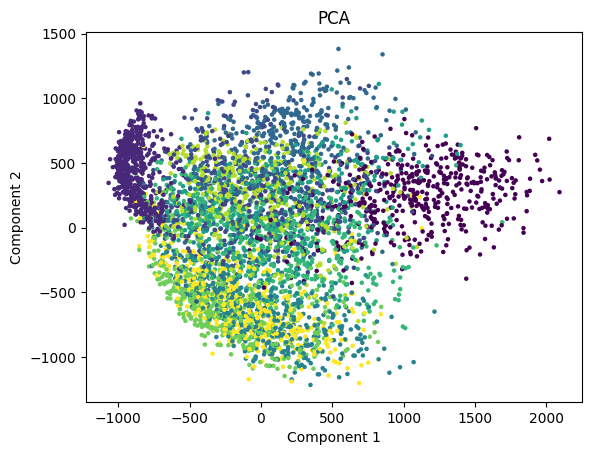

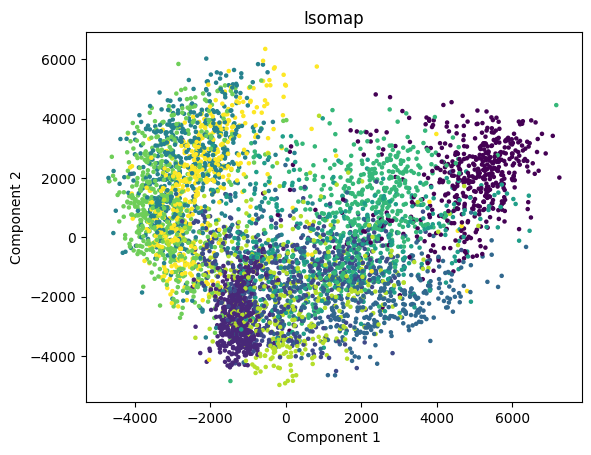

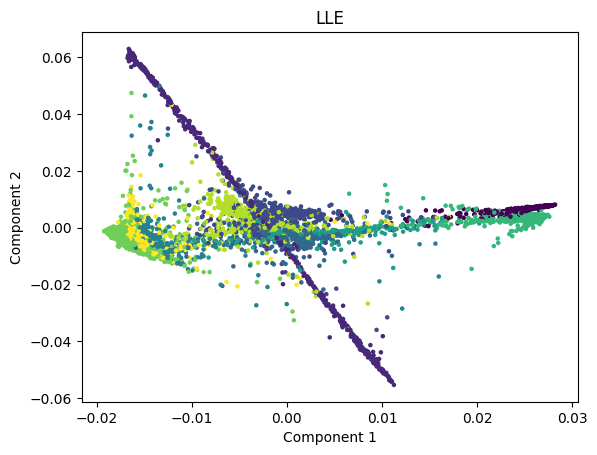

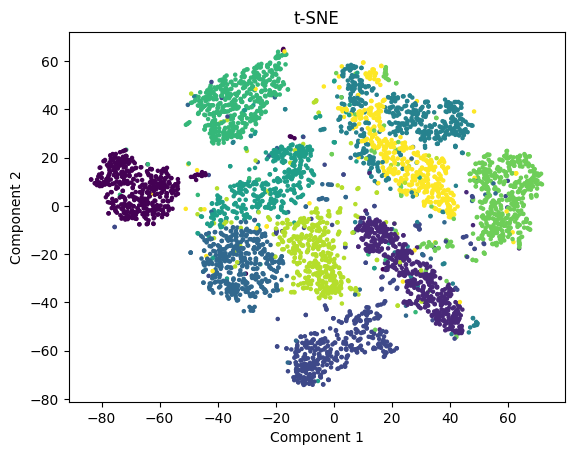

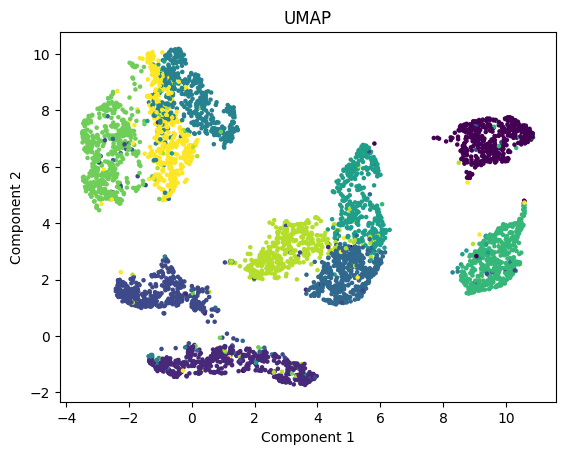

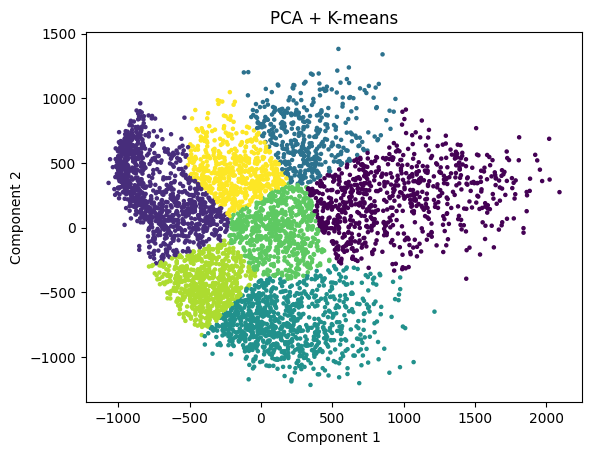

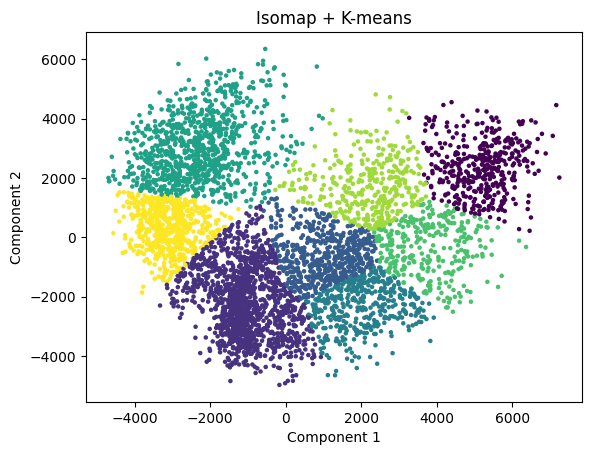

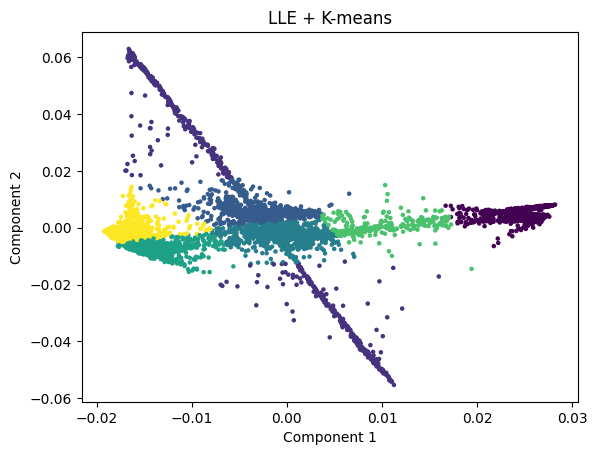

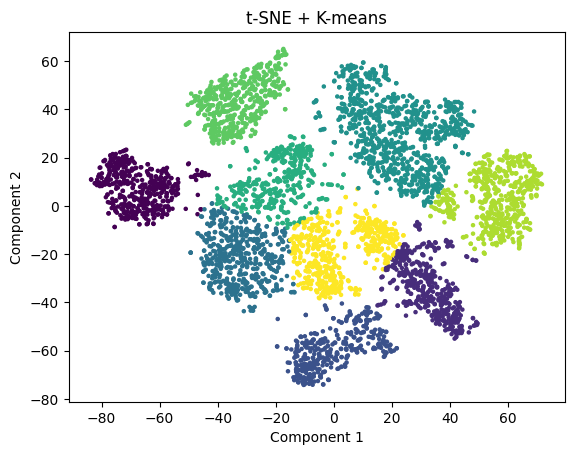

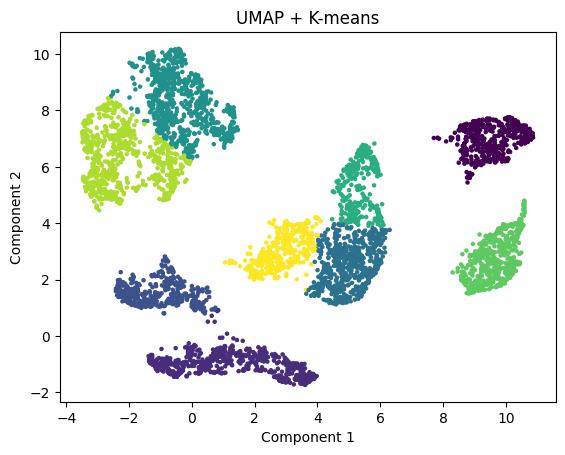


PCA cluster → digit mapping:
{0: np.int64(0), 1: np.int64(6), 2: np.int64(1), 3: np.int64(7), 4: np.int64(4), 5: np.int64(3), 6: np.int64(1), 7: np.int64(0), 8: np.int64(8), 9: np.int64(4)}

Isomap cluster → digit mapping:
{0: np.int64(0), 1: np.int64(1), 2: np.int64(4), 3: np.int64(3), 4: np.int64(1), 5: np.int64(2), 6: np.int64(7), 7: np.int64(6), 8: np.int64(5), 9: np.int64(4)}

LLE cluster → digit mapping:
{0: np.int64(0), 1: np.int64(4), 2: np.int64(1), 3: np.int64(1), 4: np.int64(5), 5: np.int64(2), 6: np.int64(1), 7: np.int64(7), 8: np.int64(1), 9: np.int64(3)}

t-SNE cluster → digit mapping:
{0: np.int64(3), 1: np.int64(8), 2: np.int64(0), 3: np.int64(1), 4: np.int64(4), 5: np.int64(2), 6: np.int64(5), 7: np.int64(7), 8: np.int64(6), 9: np.int64(4)}

UMAP cluster → digit mapping:
{0: np.int64(3), 1: np.int64(7), 2: np.int64(2), 3: np.int64(0), 4: np.int64(6), 5: np.int64(1), 6: np.int64(4), 7: np.int64(5), 8: np.int64(8), 9: np.int64(1)}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, LocallyLinearEmbedding, TSNE
from sklearn.cluster import KMeans
from collections import Counter
import umap

# 1. Load MNIST dataset
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
y = y.astype(int)

n_samples = 5000
X = X[:n_samples]
y = y[:n_samples]

# 2. Dimensionality reduction (d = 2)
reducers = {
    "PCA": PCA(n_components=2),
    "Isomap": Isomap(n_components=2, n_neighbors=10),
    "LLE": LocallyLinearEmbedding(n_components=2, n_neighbors=10),
    "t-SNE": TSNE(n_components=2, perplexity=30, init="random", random_state=0),
    "UMAP": umap.UMAP(n_components=2, random_state=0)
}

embeddings = {}

for name, reducer in reducers.items():
    embeddings[name] = reducer.fit_transform(X)

for name, Z in embeddings.items():
    plt.figure()
    plt.scatter(Z[:, 0], Z[:, 1], c=y, s=5)
    plt.title(f"{name}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

# 3. K-means clustering (k = 10)
cluster_labels = {}
majority_maps = {}

for name, Z in embeddings.items():
    kmeans = KMeans(n_clusters=10, random_state=0, n_init=10)
    clusters = kmeans.fit_predict(Z)
    cluster_labels[name] = clusters

    # 4. Majority vote labeling
    cluster_to_digit = {}
    for c in range(10):
        digits_in_cluster = y[clusters == c]
        cluster_to_digit[c] = Counter(digits_in_cluster).most_common(1)[0][0]

    majority_maps[name] = cluster_to_digit
    predicted_digits = np.array([cluster_to_digit[c] for c in clusters])

    plt.figure()
    plt.scatter(Z[:, 0], Z[:, 1], c=predicted_digits, s=5)
    plt.title(f"{name} + K-means")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

for name, mapping in majority_maps.items():
    print(f"\n{name} cluster → digit mapping:")
    print(mapping)
